# IEEE Retinex Image Enhancement Study
**Comparative implementation of SSR, MSR, MSRCR, IRIE, MSRINTE, and RBPCELA.**

### Block 1: Imports and Display Utilities
Since OpenCV loads images in BGR format and Matplotlib expects RGB, we define a helper function to safely display our high-res images directly inside the notebook.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, img):
    """Helper function to safely display OpenCV images in Jupyter."""
    plt.figure(figsize=(12, 8))
    # Check if image is color (3 channels) or grayscale (2 channels)
    if len(img.shape) == 3:
        # Convert BGR to RGB for Matplotlib
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
        
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

# Global Resize Parameter to keep matrix math fast during testing
SCALE_PERCENT = 25

### Block 2: Foundation DSP Functions
These are the core mathematical operations and low-pass filters that power the Retinex algorithms. We use a separable 2D filter (`cv2.sepFilter2D`) to reduce the algorithmic complexity from $O(N^2)$ to $O(2N)$.

In [3]:
def get_ksize(sigma):
    """Calculates optimal kernel size for a given Gaussian standard deviation."""
    ksize = int(((sigma - 0.8) / 0.15) + 3.0)
    if ksize % 2 == 0:
        ksize += 1
    return max(3, ksize)

def get_gaussian_blur(img, ksize=0, sigma=5):
    """Applies a highly optimized separable 2D Gaussian Blur."""
    if ksize == 0:
        ksize = get_ksize(sigma)
    sep_k = cv2.getGaussianKernel(ksize, sigma)
    return cv2.sepFilter2D(img, -1, sep_k, sep_k)

def sigmoid(x, alpha=5.0):
    """Sigmoid activation function used for MSRINTE night-enhancement."""
    return 1.0 / (1.0 + np.exp(-alpha * x))

def color_balance(img, low_per=1, high_per=1):
    """Contrast stretching via histogram equalization (used in MSRCR)."""
    tot_pix = img.shape[1] * img.shape[0]
    low_count = tot_pix * low_per / 100
    high_count = tot_pix * (100 - high_per) / 100
    
    ch_list = [img] if len(img.shape) == 2 else cv2.split(img)
    cs_img = []
    
    for ch in ch_list:
        cum_hist_sum = np.cumsum(cv2.calcHist([ch], [0], None, [256], (0, 256)))
        li, hi = np.searchsorted(cum_hist_sum, (low_count, high_count))
        if li == hi:
            cs_img.append(ch)
            continue
            
        lut = np.array([0 if j < li else (255 if j > hi else round((j - li) / (hi - li) * 255)) 
                        for j in np.arange(0, 256)], dtype='uint8')
        cs_img.append(cv2.LUT(ch, lut))
        
    return np.squeeze(cs_img) if len(cs_img) == 1 else cv2.merge(cs_img)

print("Block 2 Loaded: DSP Utilities Ready.")

Block 2 Loaded: DSP Utilities Ready.


### Block 3: Single and Multi-Scale Retinex (SSR / MSR)
These are the foundational algorithms based on Land's original color constancy theory. 
* **SSR:** Extracts illumination using a single Gaussian variance (sigma).
* **MSR:** Averages multiple variances to balance high-frequency details with global lighting.

In [4]:
def ssr(img, sigma):
    """
    Single-Scale Retinex
    Formula: R = log(S) - log(S * G)
    """
    # Convert to float and offset by 1 to prevent log(0) math domain errors
    img_float = np.float64(img) + 1.0
    
    # Estimate the illumination map (I)
    illum_map = get_gaussian_blur(img_float, ksize=0, sigma=sigma) + 1.0
    
    # Isolate reflectance in the log domain
    retinex_log = np.log10(img_float) - np.log10(illum_map)
    
    # Normalize back to 0-255 visual range (cv2.normalize is highly optimized)
    retinex_normalized = cv2.normalize(retinex_log, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC3)
    
    return retinex_normalized

def msr(img, sigma_scales, apply_normalization=True):
    """
    Multi-Scale Retinex
    Averages multiple SSR outputs (e.g., small, medium, and large blurs).
    """
    img_float = np.float64(img) + 1.0
    msr_out = np.zeros_like(img_float)
    
    # Accumulate the log differences for every scale provided
    for sigma in sigma_scales:
        illum_map = get_gaussian_blur(img_float, ksize=0, sigma=sigma) + 1.0
        msr_out += np.log10(img_float) - np.log10(illum_map)
        
    # Average the result by the total number of scales
    msr_out = msr_out / len(sigma_scales)
    
    if apply_normalization:
        msr_normalized = cv2.normalize(msr_out, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC3)
        return msr_normalized
    
    # If used as a stepping stone for MSRCR, we return the raw float data
    return msr_out

print("Block 3 Loaded: SSR and MSR Ready.")

Block 3 Loaded: SSR and MSR Ready.


### Block 4: Advanced IEEE Image Enhancement Variants
Implementations based on the comparative study by Parihar and Singh (2018).
* **MSRCR:** Adds a Color Restoration Function (CRF) and histogram equalization to prevent MSR from looking flat.
* **IRIE:** Prevents color shifting and edge halos by operating exclusively on the V-channel of the HSV color space using a Bilateral Filter.
* **MSRINTE:** Designed for night photography. Replaces the aggressive logarithmic subtraction with a gentle Sigmoid curve to prevent amplifying dark noise.
* **RBPCELA:** Applies an Adaptive Gamma Correction power-law to forcefully restore perceptual contrast lost during the illumination extraction.

In [5]:
def msrcr(img, sigma_scales=[15, 80, 250], alpha=125, beta=46, G=192, b=-30, low_per=1, high_per=1):
    """Multi-Scale Retinex with Color Restoration."""
    img_float = np.float64(img) + 1.0
    msr_img = msr(img_float, sigma_scales, apply_normalization=False)
    
    # Color Restoration Function (CRF)
    crf = beta * (np.log10(alpha * img_float) - np.log10(np.sum(img_float, axis=2, keepdims=True)))
    msrcr_out = G * (msr_img * crf - b)
    
    msrcr_norm = cv2.normalize(msrcr_out, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC3)
    return color_balance(msrcr_norm, low_per, high_per)

def irie_enhance(img, d=15, sigma_color=75, sigma_space=75):
    """Improved Retinex Image Enhancement (HSV + Bilateral Filter)."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    # Isolate illumination using edge-preserving filter
    illum_map = cv2.bilateralFilter(v, d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    
    v_float = np.float64(v) + 1.0
    illum_float = np.float64(illum_map) + 1.0
    
    retinex_log = np.log10(v_float) - np.log10(illum_float)
    v_enhanced = cv2.normalize(retinex_log, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
    
    return cv2.cvtColor(cv2.merge([h, s, v_enhanced]), cv2.COLOR_HSV2BGR)

def msrinte_enhance(img, sigma=80, alpha=5.0):
    """MSR Improvement for Night Time Enhancement (Sigmoid Subtraction)."""
    # Normalize inputs around 0 for the Sigmoid curve (-0.5 to 0.5)
    img_norm = (np.float64(img) / 255.0) - 0.5
    
    img_float = np.float64(img) + 1.0
    illum_map = get_gaussian_blur(img_float, ksize=0, sigma=sigma) + 1.0
    illum_norm = (np.float64(illum_map) / 255.0) - 0.5
    
    # The MSRINTE swap: Sigmoid instead of Log
    retinex_sigmoid = sigmoid(img_norm, alpha) - sigmoid(illum_norm, alpha)
    
    return cv2.normalize(retinex_sigmoid, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC3)

def rbpcela_enhance(img, sigma=80, gamma=0.6):
    """Retinex Based Perceptual Contrast Enhancement (Gamma Correction)."""
    # 1. Base Illumination Extraction
    img_float = np.float64(img) + 1.0
    illum_map = get_gaussian_blur(img_float, ksize=0, sigma=sigma) + 1.0
    retinex_log = np.log10(img_float) - np.log10(illum_map)
    retinex_norm = cv2.normalize(retinex_log, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8UC3)
    
    # 2. Adaptive Gamma Correction to punch up local contrast
    norm_out = retinex_norm / 255.0
    gamma_corrected = np.power(norm_out, gamma) * 255.0
    
    return np.uint8(gamma_corrected)

print("Block 4 Loaded: MSRCR, IRIE, MSRINTE, and RBPCELA Ready.")

Block 4 Loaded: MSRCR, IRIE, MSRINTE, and RBPCELA Ready.


### Block 5: Execution Switchboard & Visual Comparison
This block loads the target image, dynamically resizes it for rapid matrix processing, and runs the selected IEEE algorithms. 
The results are plotted in a Matplotlib grid for direct visual comparison. 
*Note: You can easily swap which algorithms are displayed by changing the function calls in the "Switchboard" section.*

Image loaded successfully.
Resized to 1024x768 for rapid testing.

Processing algorithms... (This may take a few seconds depending on image size)
SSR Complete.
MSRCR Complete.
IRIE Complete.
MSRINTE Complete.
RBPCELA Complete.


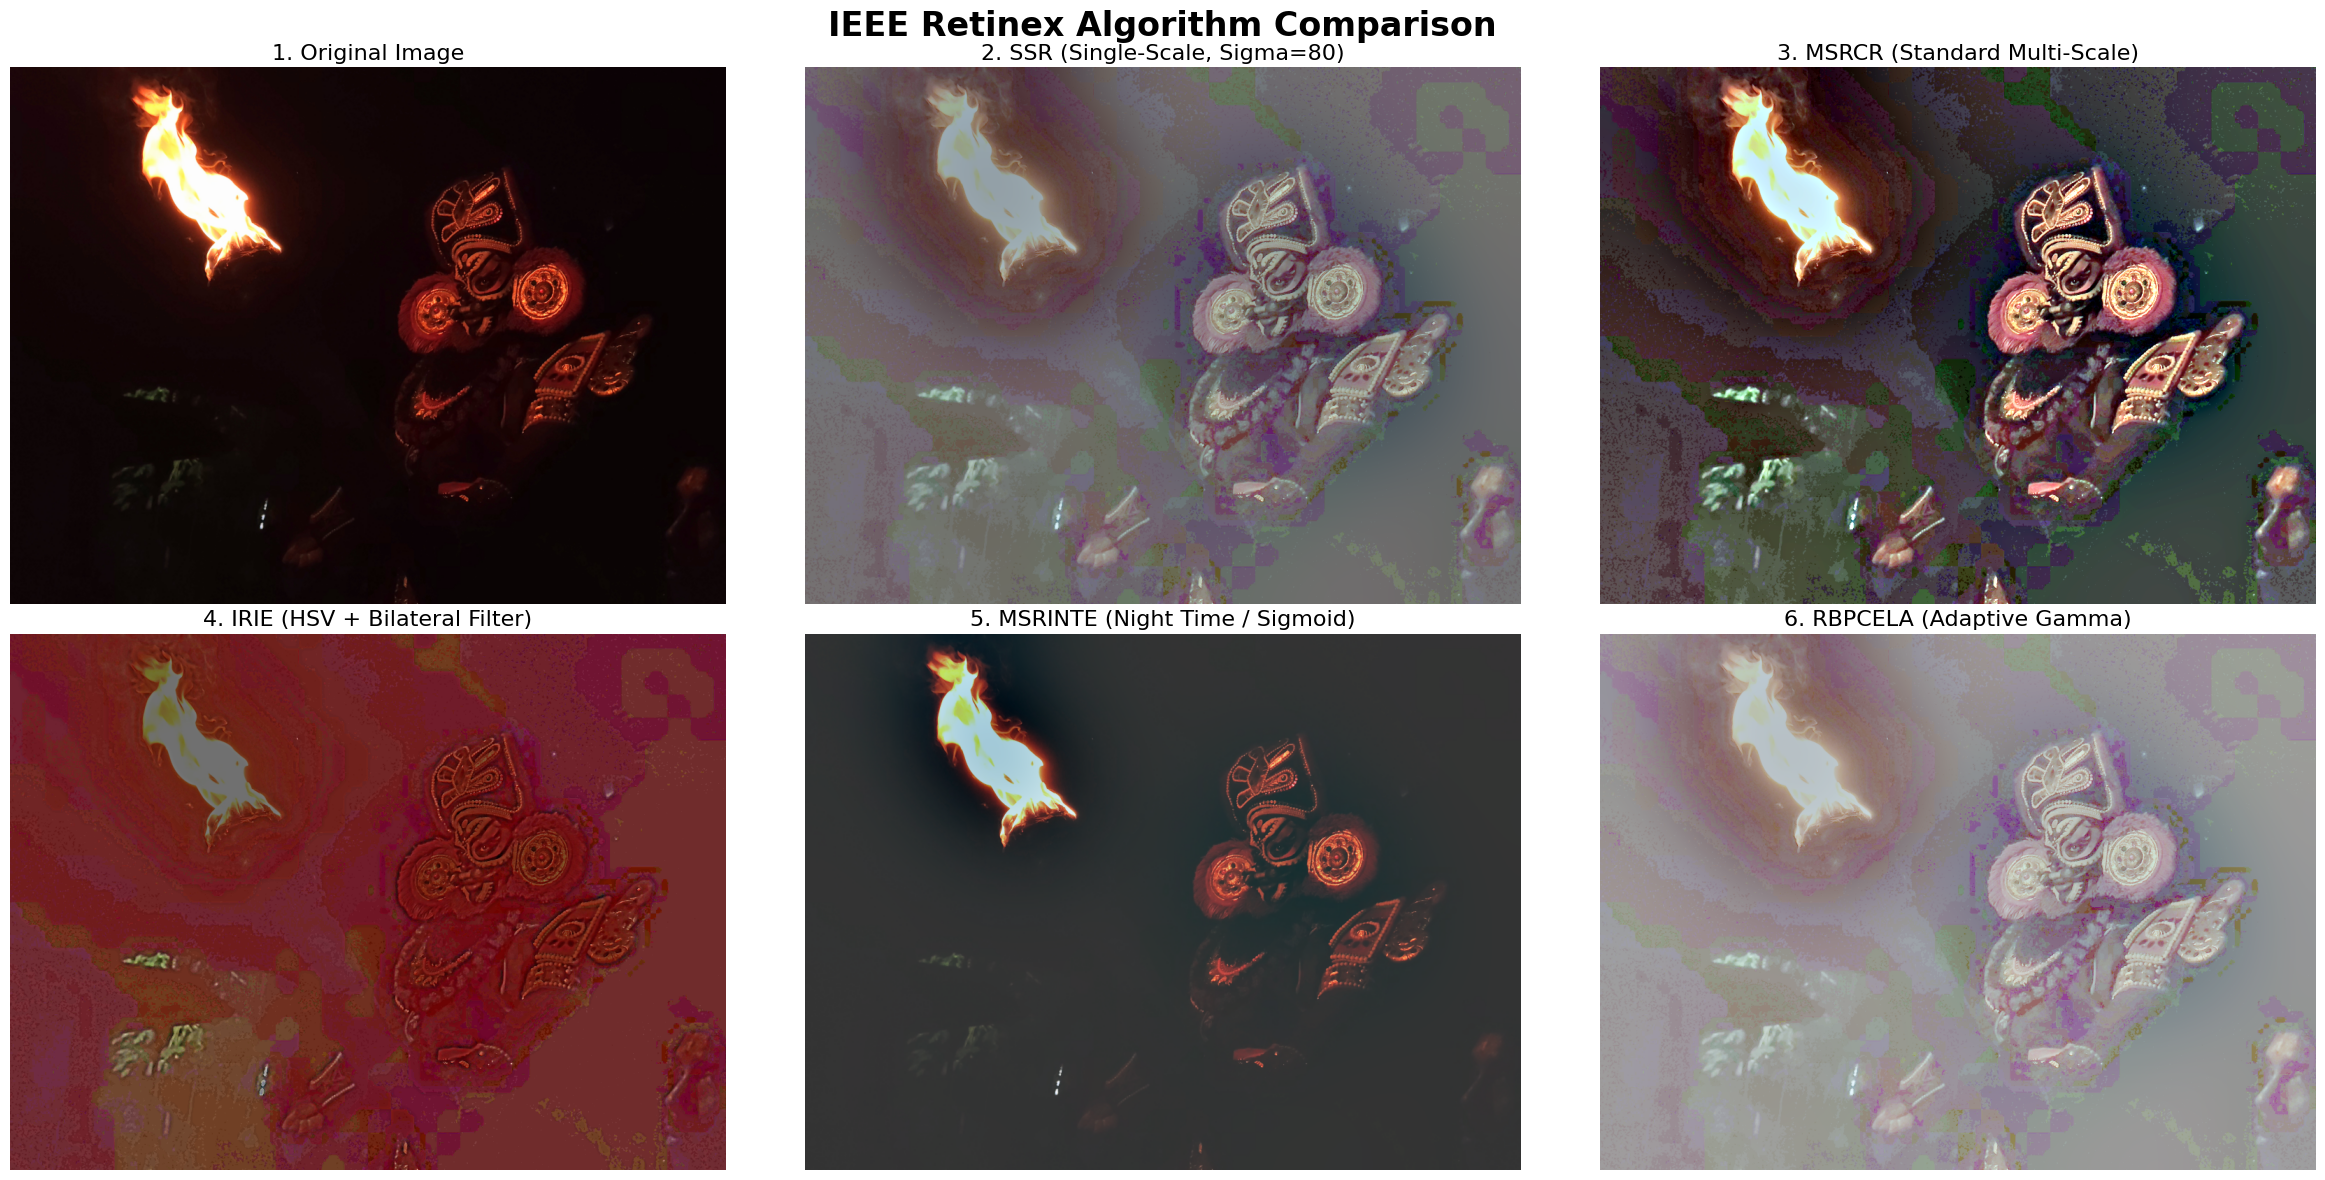

In [6]:
# ==========================================
# 1. LOAD AND PREP THE IMAGE
# ==========================================
image_path = "image.jpg" # Change this to your image's filename
original_img = cv2.imread(image_path)

if original_img is None:
    print(f"ERROR: Could not load '{image_path}'. Check the spelling and make sure it is in the same folder as this notebook.")
else:
    print("Image loaded successfully.")
    
    # Resize for performance (using SCALE_PERCENT from Block 1)
    width = int(original_img.shape[1] * SCALE_PERCENT / 100)
    height = int(original_img.shape[0] * SCALE_PERCENT / 100)
    test_img = cv2.resize(original_img, (width, height), interpolation=cv2.INTER_AREA)
    print(f"Resized to {width}x{height} for rapid testing.\n")

    # ==========================================
    # 2. THE SWITCHBOARD (Run Algorithms Here)
    # ==========================================
    print("Processing algorithms... (This may take a few seconds depending on image size)")
    
    out_ssr = ssr(test_img, sigma=80)
    print("SSR Complete.")

    out_msrcr = msrcr(test_img)
    print("MSRCR Complete.")
    
    out_irie = irie_enhance(test_img)
    print("IRIE Complete.")
    
    out_msrinte = msrinte_enhance(test_img)
    print("MSRINTE Complete.")

    out_rbpcela = rbpcela_enhance(test_img)
    print("RBPCELA Complete.")

    # ==========================================
    # 3. THE DISPLAY GRID (Expanded to 2x3)
    # ==========================================
    # Create a 2x3 grid of plots (Width=24, Height=12 to fit 3 columns)
    fig, axs = plt.subplots(2, 3, figsize=(24, 12))
    fig.suptitle("IEEE Retinex Algorithm Comparison", fontsize=24, fontweight='bold', y=0.98)

    # Helper function to prep images for Matplotlib
    def prep_plot(img):
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- TOP ROW ---
    # Top Left: Original
    axs[0, 0].imshow(prep_plot(test_img))
    axs[0, 0].set_title("1. Original Image", fontsize=16)
    axs[0, 0].axis('off')

    # Top Middle: SSR
    axs[0, 1].imshow(prep_plot(out_ssr))
    axs[0, 1].set_title("2. SSR (Single-Scale, Sigma=80)", fontsize=16)
    axs[0, 1].axis('off')

    # Top Right: MSRCR
    axs[0, 2].imshow(prep_plot(out_msrcr))
    axs[0, 2].set_title("3. MSRCR (Standard Multi-Scale)", fontsize=16)
    axs[0, 2].axis('off')

    # --- BOTTOM ROW ---
    # Bottom Left: IRIE
    axs[1, 0].imshow(prep_plot(out_irie))
    axs[1, 0].set_title("4. IRIE (HSV + Bilateral Filter)", fontsize=16)
    axs[1, 0].axis('off')

    # Bottom Middle: MSRINTE
    axs[1, 1].imshow(prep_plot(out_msrinte))
    axs[1, 1].set_title("5. MSRINTE (Night Time / Sigmoid)", fontsize=16)
    axs[1, 1].axis('off')

    # Bottom Right: RBPCELA
    axs[1, 2].imshow(prep_plot(out_rbpcela))
    axs[1, 2].set_title("6. RBPCELA (Adaptive Gamma)", fontsize=16)
    axs[1, 2].axis('off')

    plt.tight_layout()
    plt.show()